# Complementary Macroeconomics

## 10th Session

# RBC Model Simulation, VAR & Impulse Responses.ipynb

# Introduction to a Special Case of the RBC Model

This notebook explores a streamlined version of the Real Business Cycle (RBC) model, inspired by David Romer's *Advanced Macroeconomics*, Chapter 5: **Real-Business-Cycle Theory**. By removing government intervention and assuming full capital depreciation each period, we isolate the core dynamics of consumption, labor supply, and production in a frictionless economy.

This simplification enables us to derive closed-form analytical solutions and simulate the model’s behavior using Python. We focus on:

- The evolution of technology shocks
- The behavior of output, investment, and wages
- The structure and implications of the value function

We begin by laying out the model’s equations and assumptions, then solve for key relationships using Bellman’s Equation and a log-linear guess for the value function. Finally, we simulate impulse response functions (IRFs) to visualize how technology shocks propagate through the economy.


## The RBC Model Framework

The RBC model, under these assumptions, is defined by the following key equations:

1. **Production Function**: 

   $Y_t = K_t^{\alpha} (A_t L_t)^{1-\alpha}$

2. **Capital Accumulation**: 

   $K_{t+1} = Y_t - C_t$ 

3. **Technology Dynamics**: 
   
    $\ln A_t = \bar A + gt + \tilde A_t$

   $\tilde A_t = \rho_A \tilde A_{t+1} + \varepsilon_{A,t}$


4. **Labor Supply Dynamics**: 
   
    $\ln N_t = \bar N + nt$

5. **Utility Function**: 
   
    $u_t = \ln c_t + b \ln (1 - ell_t)$

To simplify our analysis, we set $n = g = \bar A = \bar N = 0$. Consequently, population is normalized to one, leading to:

$\ln N_t = 0 \rightarrow N_t = 1$

This adjustment allows us to equate labor supply per person, $ell_t$, to total labor supply. The production function then transforms to:

$Y_t = K_{t}^{\alpha}[A_t ell_t]^{1-\alpha}$

### Technology Adjustments

With $g$ and $\bar{A}$ set to zero, the technology equation simplifies to:

$
\ln A_t = \tilde{A}_t \Rightarrow \ln A_t = \rho_A \ln A_{t-1} + \varepsilon_{A,t}
$

## Value Function and Optimization

### Defining the Value Function

At time $t$, the value function can be expressed as:

$
V_t = \max E_t \left[ \sum_{s=t}^{\infty} e^{-\rho (s-t)} \left( \ln C_s + b \ln(1 - l_s) \right) \right]
$

This value function represents the expected present value of lifetime utility, subject to the constraints imposed by the production function, capital accumulation, and technology dynamics.

### Bellman's Equation

The relationship between the value function and current choices can be captured by Bellman's Equation:

$
V_t(K_t, A_t) = \max_{C_t, \ell_t} \left[ \ln C_t + b \ln(1 - \ell_t) + e^{-\rho} E_t \left[ V_{t+1}(K_{t+1}, A_{t+1}) \right] \right]
$

This equation emphasizes that the current value function is determined by today's utility plus the expected future value, appropriately discounted.

### Guessing the Value Function Form

We hypothesize that the value function takes a log-linear form:

$
V(K_t, A_t) = \beta_0 + \beta_K \ln K_t + \beta_A \ln A_t
$

Substituting this guess into Bellman's Equation provides a pathway to derive the optimal consumption and labor supply decisions.

## Deriving Key Relationships

### Consumption and Output Ratio

Through optimization, we find the ratio of consumption to output:

$
\frac{C_t}{Y_t} = \frac{1}{1 + e^{-\rho} \beta_K}
$

This ratio remains independent of capital \(K_t\) and technology \(A_t\).

### Labor Supply Dynamics

The optimal labor supply per person is derived as:

$
\ell_t = \frac{(1 - \alpha)(1 + e^{-\rho} \beta_K)}{(1 - \alpha)(1 + e^{-\rho} \beta_K) + b}
$

This expression illustrates that labor supply is also independent of $K_t$ and $A_t$


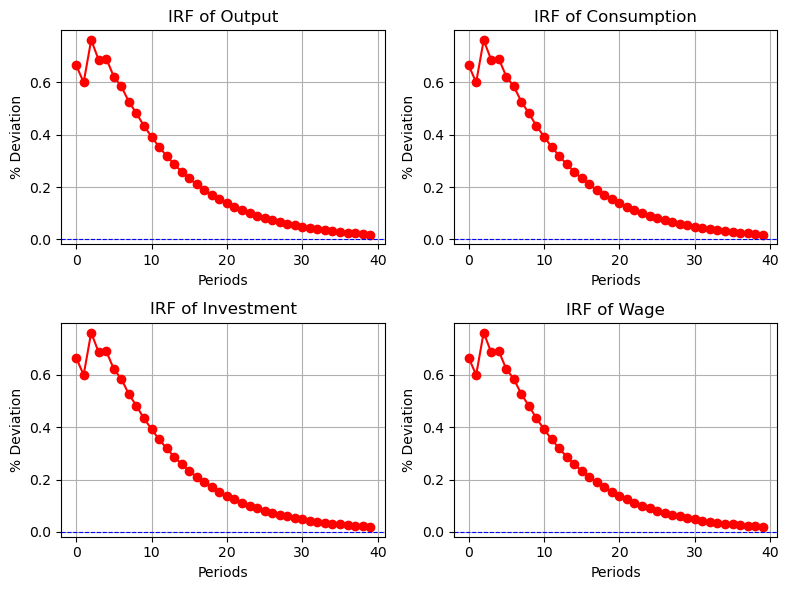

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)

# Parameters
n = 0
g = 0
rho_A = 0.9
sigma_eps = 0.02
alpha = 1/3
rho = 0.03
beta_0 = 0.05
b = 2

T = 50
T_irf = 40

ell_t = (1 - alpha) / ((1 - alpha) + b * (1 - alpha * np.exp(-rho)))
beta_A = (1 - alpha) / (1 - alpha * np.exp(-rho) * (1 - rho_A * np.exp(-rho)))
beta_K = alpha / (1 - alpha * np.exp(-rho))

Y_t = np.zeros(T)
ln_Y_t = np.zeros(T)
ln_A_t = np.zeros(T)
epsilon = np.random.normal(0, sigma_eps, T)

K_t = np.zeros(T)
ln_K_t = np.zeros(T)

C_t = np.zeros(T)
ln_C_t = np.zeros(T)

I_t = np.zeros(T)
w_t = np.zeros(T)

#Initial values
K_t[0] = 0.43
ln_K_t[0] = np.log(K_t[0])
ln_A_t[0] = 0

ln_Y_t[0] = alpha * ln_K_t[0] + (1 - alpha) * ln_A_t[0] +  (1 - alpha) * np.log(ell_t)
Y_t[0] = np.exp(ln_Y_t[0])

ln_C_t[0] = -np.log(1 + np.exp(-rho) * beta_K) + ln_Y_t[0]
C_t[0] = np.exp(ln_C_t[0])

I_t[0] = Y_t[0] - C_t[0]
w_t[0] = (1 - alpha) * (Y_t[0] / ell_t)

for t in range(1, T):
    ln_A_t[t] = rho_A * ln_A_t[t-1] + epsilon[t]
    ln_Y_t[t] = alpha * ln_K_t[t-1] + (1 - alpha) * ln_A_t[t] + (1 - alpha) * np.log(ell_t)
    Y_t[t] = np.exp(ln_Y_t[t])
    ln_C_t[t] = -np.log(1 + np.exp(-rho) * beta_K) + ln_Y_t[t]
    C_t[t] = np.exp(ln_C_t[t])
    ln_K_t[t] = ln_K_t[t-1] + ln_Y_t[t] - ln_C_t[t]
    K_t[t] = np.exp(ln_K_t[t])
    I_t[t] = Y_t[t] - C_t[t]
    w_t[t] = (1 - alpha) * (Y_t[t] / ell_t)

#Value function
def value_func(K, lnA):
    return (
        alpha * np.log(K)
        + (1 - alpha) * lnA
        + (1 - alpha) * np.log(ell_t)
        - np.log(1 + np.exp(-rho) * beta_K)
        + b * np.log(b / ((1 - alpha) * (1 + np.exp(-rho) * beta_K) + b))
        + np.exp(-rho) * beta_0
        + np.exp(-rho) * beta_K * (
            np.log(np.exp(-rho) * beta_K)
            - np.log(1 + np.exp(-rho) * beta_K)
            + alpha * np.log(K)
            + (1 - alpha) * lnA
            + (1 - alpha) * np.log(ell_t)
        )
        + np.exp(-rho) * beta_A * rho_A * lnA
    )

V_t = value_func(K_t, ln_A_t)


T      = 50         
T_irf  = 40         
alpha  = 1/3        
rho_A  = 0.9       
rho    = 0.03       
b      = 2          

C_Y = 1 - alpha * np.exp(-rho)
I_Y = alpha * np.exp(-rho)
ell = (1 - alpha) / ((1 - alpha) + b * (1 - alpha * np.exp(-rho)))

shock_size = 0.01   

K0    = 0.43
lnA0  = 0.0
lnK0  = np.log(K0)

def simulate(eps):
    lnA = np.zeros(T)
    lnK = np.zeros(T)
    lnY = np.zeros(T)
    lnC = np.zeros(T)
    lnI = np.zeros(T)
    lnW = np.zeros(T)

    lnA[0] = lnA0 + eps[0]
    lnK[0] = lnK0

    # period 0
    lnY[0] = alpha * lnK[0] + (1-alpha) * lnA[0] + (1-alpha)*np.log(ell)
    lnC[0] = lnY[0] + np.log(C_Y)
    lnI[0] = lnY[0] + np.log(I_Y)
    lnW[0] = lnY[0] + np.log(1-alpha) - np.log(ell)

    for t in range(1, T):
        lnA[t] = rho_A * lnA[t-1] + eps[t]

        lnY[t] = alpha * lnK[t-1] + (1-alpha) * lnA[t] + (1-alpha)*np.log(ell)

        lnC[t] = lnY[t] + np.log(C_Y)
        lnI[t] = lnY[t] + np.log(I_Y)
        lnW[t] = lnY[t] + np.log(1-alpha) - np.log(ell)

        lnK[t] = lnI[t-1]

    return {'lnA': lnA, 'lnK': lnK, 'lnY': lnY,
            'lnC': lnC, 'lnI': lnI, 'lnW': lnW}


eps_base = np.zeros(T)

eps_shock = np.zeros(T)
eps_shock[0] = shock_size

sim_base  = simulate(eps_base)
sim_shock = simulate(eps_shock)

horizon = np.arange(T_irf)
irf = {}
for var in ('lnY','lnC','lnI','lnW'):
    irf[var] = 100 * (sim_shock[var][:T_irf] - sim_base[var][:T_irf])

plt.figure(figsize=(8,6))
labels = {
    'lnY': 'Output',
    'lnC': 'Consumption',
    'lnI': 'Investment',
    'lnW': 'Wage'
}
for i, var in enumerate(('lnY','lnC','lnI','lnW'), 1):
    plt.subplot(2,2,i)
    plt.plot(horizon, irf[var], marker='o', color = "r")
    plt.axhline(0, color= "blue", lw=0.8, ls='--')
    plt.title(f'IRF of {labels[var]}')
    plt.xlabel('Periods')
    plt.ylabel('% Deviation')
    plt.grid(True)

plt.tight_layout()
plt.show()



# Understanding the Impulse Response Function (IRF) Code

This guide will walk you through the process of simulating an economic model to understand how it responds to a technology shock. Let’s break it down step by step!

## 1. Setting Up the Shock and Time Frame

First, we need to define the size of our technology shock and how long we want to observe its effects.

```python
T_irf   = 40       # number of periods to plot
shock   = 0.01     # a 1% one-off technology shock in ln A
```

- Here, we’re using a small shock of **0.01**, which represents a **1% increase** in log-technology. 
- The variable `T_irf` tells us how many periods we’ll be tracking the responses—**40 periods** in this case.

---

## 2. Creating a Simulation Function

Next, we’ll create a function that simulates our model based on a sequence of shocks.

```python
def simulate(eps):
    # eps: array of length T containing shocks to ln A_t
    # returns dict with ln-series for A, K, Y, C, I, W
    ...
    return {'lnA': lnA, 'lnK': lnK, 'lnY': lnY, 'lnC': lnC, 'lnI': lnI, 'lnW': lnW}
```

- This function takes an array of shocks (`eps`) and calculates the log-series for key economic variables: **A (technology), K (capital), Y (output), C (consumption), I (investment), and W (wages)**.
- Inside the function, we:
  - Evolve `lnA` using an autoregressive model (AR(1)).
  - Compute `lnY` using the Cobb-Douglas production function in log form.
  - Maintain constant ratios for `lnC`, `lnI`, and `lnW`.
  - Update capital with the previous period’s investment: `lnK[t] = lnI[t-1]`.

---

## 3. Generating Baseline and Shocked Paths

Now, let’s run our model with and without the shock.

```python
eps_base  = np.zeros(T)        # no shocks
eps_shock = np.zeros(T)
eps_shock[0] = shock           # 1% shock at t = 0

sim_base  = simulate(eps_base)
sim_shock = simulate(eps_shock)
```

- `sim_base` represents the economy without any shocks.
- `sim_shock` shows the economy's path when we apply our shock at the first period.

---

## 4. Calculating the IRFs as Percent Deviations

Next, we’ll calculate the impulse response functions (IRFs) to see how much each variable deviates from the baseline.

```python
horizon = np.arange(T_irf)
irf = {}
for var in ('lnY','lnC','lnI','lnW'):
    irf[var] = 100 * (
      sim_shock[var][:T_irf] 
      - sim_base[var][:T_irf]
    )
```

- For each variable (output, consumption, investment, and wages), we subtract the baseline values from the shocked values.
- Multiplying by **100** converts these log deviations into approximate percentage changes.
- The result, `irf[var]`, gives us a series of percent deviations for each variable over the 40 periods.

---

## 5. Visualizing the IRFs

Finally, let’s plot the results to visualize the responses.

```python
labels = {'lnY':'Output','lnC':'Consumption','lnI':'Investment','lnW':'Wage'}

plt.figure(figsize=(8,6))
for i, var in enumerate(('lnY','lnC','lnI','lnW'), 1):
    plt.subplot(2,2,i)
    plt.plot(horizon, irf[var], marker='o', color = "r")
    plt.axhline(0, color= "blue", lw=0.8, ls='--')
    plt.title(f'IRF of {labels[var]}')
    plt.xlabel('Periods')
    plt.ylabel('% deviation')
    plt.grid(True)

plt.tight_layout()
plt.show()
```

- We create a **2x2 grid** of plots, each showing the IRF for one of our key variables.
- A dashed line at zero helps us see whether the responses are positive or negative.
- Clear labels and titles make it easy to understand what each plot represents.



## Romer’s Quotation

“Despite the output dynamics, this special case of the model does not match major features of fluctuations very well. Most obviously, the saving rate is constant so that consumption and investment are equally volatile and labor input does not vary. In practice, as we saw in Section 5.1, investment varies much more than consumption, and employment and hours are strongly procyclical. In addition, the model predicts that the real wage is highly procyclical.” — David Romer, Advanced Macroeconomics (5th ed.), p. 206